# FA HW 2

In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model

### pip install yfinance pandas numpy matplotlib statsmodels arch

### Yahoo Finance Stock Collection

In [16]:

# ──  CURRENT DJIA TICKERS ────────────────────────────────────────────────
# As of February 2026. Update this list if the index composition changes.
# Source: S&P Dow Jones Indices / Wall Street Journal committee.
DJIA_TICKERS = [
    "AAPL",  # Apple
    "AMGN",  # Amgen
    "AMZN",  # Amazon
    "AXP",   # American Express
    "BA",    # Boeing
    "CAT",   # Caterpillar
    "CRM",   # Salesforce
    "CSCO",  # Cisco
    "CVX",   # Chevron
    "DIS",   # Walt Disney
    "GS",    # Goldman Sachs
    "HD",    # Home Depot
    "HON",   # Honeywell
    "IBM",   # IBM
    "JNJ",   # Johnson & Johnson
    "JPM",   # JPMorgan Chase
    "KO",    # Coca-Cola
    "MCD",   # McDonald's
    "MMM",   # 3M
    "MRK",   # Merck
    "MSFT",  # Microsoft
    "NKE",   # Nike
    "NVDA",  # Nvidia
    "PG",    # Procter & Gamble
    "SHW",   # Sherwin-Williams
    "TRV",   # Travelers
    "UNH",   # UnitedHealth Group
    "V",     # Visa
    "VZ",    # Verizon
    "WMT",   # Walmart
]

# ── scrape tickers dynamically from Wikipedia instead ────────────
def get_djia_tickers_from_wikipedia() -> list[str]:
    """
    Scrapes the current DJIA component tickers from Wikipedia.
    Requires: pip install lxml  (pandas.read_html dependency)
    Falls back to the hardcoded list if scraping fails.
    """
    try:
        url = "https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average"
        tables = pd.read_html(url, attrs={"class": "wikitable"})
        # The components table has a 'Symbol' column
        for tbl in tables:
            if "Symbol" in tbl.columns:
                tickers = tbl["Symbol"].str.strip().tolist()
                if len(tickers) == 30:
                    return tickers
    except Exception as e:
        print(f"[WARN] Wikipedia scrape failed ({e}). Using hardcoded list.")
    return DJIA_TICKERS


# ──  USER SETTINGS ──────────────────────────────────────────────────────
START = "2011-03-01" #Start Date 
END   = "2021-03-24"  # End Date        
USE_WIKIPEDIA_SCRAPE = False  # set True to always pull a fresh ticker list

# ── FETCH ──────────────────────────────────────────────────────────────
tickers = get_djia_tickers_from_wikipedia() if USE_WIKIPEDIA_SCRAPE else DJIA_TICKERS

print(f"Downloading {len(tickers)} tickers from {START} …")
raw = yf.download(
    tickers,
    start=START,
    end=END,
    auto_adjust=True,   # 'Close' is already split/dividend-adjusted
    progress=True,
    group_by="ticker",  # raw.columns is a MultiIndex: (ticker, OHLCV)
)

# ── EXTRACT & CLEAN ADJUSTED CLOSE ────────────────────────────────────
# Build a plain DataFrame: rows = dates, columns = tickers
prices = pd.DataFrame(
    {ticker: raw[ticker]["Close"] for ticker in tickers},
    index=raw.index,
)
prices.index = pd.to_datetime(prices.index)
prices.index.name = "date"

# Drop rows where ALL tickers are NaN (non-trading days that yfinance sometimes
# returns); keep rows where at least one ticker has data.
prices = prices.dropna(how="all")

print(f"Price matrix shape: {prices.shape}  ({prices.index[0].date()} → {prices.index[-1].date()})")
missing_pct = prices.isna().mean() * 100
if (missing_pct > 1).any():
    print("\n[INFO] Tickers with >1% missing data:")
    print(missing_pct[missing_pct > 1].sort_values(ascending=False).to_string())

# ── COMPUTE RETURNS ────────────────────────────────────────────────────
# Simple returns: (P_t / P_{t-1}) - 1
simple_returns = prices.pct_change()

# Log returns: ln(P_t) - ln(P_{t-1})  — equivalent to np.log(prices).diff()
log_returns = np.log(prices).diff()

# Drop the first row (all NaN returns)
simple_returns = simple_returns.iloc[1:]
log_returns    = log_returns.iloc[1:]
prices_aligned = prices.iloc[1:]          # align index for MultiIndex build

# ──  MULTIINDEX DATAFRAME ─────────────────────────────────────────────
# Level-0 keys: "price" | "ret" | "log_ret"
# Level-1 keys: ticker symbols
df_multi = pd.concat(
    [prices_aligned, simple_returns, log_returns],
    axis=1,
    keys=["price", "ret", "log_ret"],
)
df_multi.columns.names = ["metric", "ticker"]

# ──  LONG (TIDY) DATAFRAME ────────────────────────────────────────────
# One row per (date, ticker)
df_long = (
    pd.concat(
        {
            "price":   prices_aligned,
            "ret":     simple_returns,
            "log_ret": log_returns,
        },
        axis=1,
    )
    .stack(level=1)               # pivot tickers → rows
    .reset_index()
    .rename(columns={"level_1": "ticker"})
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)
# Reorder columns for readability
df_long = df_long[["date", "ticker", "price", "ret", "log_ret"]]

# ── QUICK SANITY CHECK ─────────────────────────────────────────────────
print("\n── MultiIndex head ──")
print(df_multi.head(3))

print("\n── Long-format head ──")
print(df_long.head(6))

print("\n── Annualised return summary (simple) ──")
ann_ret = simple_returns.mean() * 252
ann_vol = simple_returns.std() * np.sqrt(252)
summary = pd.DataFrame({"ann_return": ann_ret, "ann_vol": ann_vol})
summary["sharpe"] = summary["ann_return"] / summary["ann_vol"]
print(summary.sort_values("sharpe", ascending=False).round(4).to_string())

# ── OPTIONAL: SAVE TO CSV / PARQUET ───────────────────────────────────
# df_long.to_csv("djia_long.csv", index=False)
# df_long.to_parquet("djia_long.parquet", index=False)
# df_multi.to_csv("djia_multi.csv")
# df_multi.to_parquet("djia_multi.parquet")

print("\nDone. Objects available: df_multi, df_long")

[*********************100%***********************]  30 of 30 completed


Price matrix shape: (2533, 30)  (2011-03-01 → 2021-03-23)

── MultiIndex head ──
metric          price                                                      \
ticker           AAPL       AMGN    AMZN        AXP         BA        CAT   
date                                                                        
2011-03-02  10.550575  34.759617  8.6010  34.910473  55.889263  69.646362   
2011-03-03  10.773499  35.422470  8.6395  35.949177  57.608444  71.908791   
2011-03-04  10.786683  35.388660  8.5835  35.478516  57.680744  71.074188   

metric                                                  ...   log_ret  \
ticker            CRM       CSCO        CVX        DIS  ...      MSFT   
date                                                    ...             
2011-03-02  31.618328  11.970450  56.443596  37.242271  ... -0.003063   
2011-03-03  32.127151  11.989864  56.836330  37.913307  ...  0.004591   
2011-03-04  32.102451  11.905745  56.596336  37.465942  ... -0.009588   

metric           

### Lagrange Multiplier Lag 1 test - Ranking for all 30 stocks

In [17]:

results = []

LM_LAGS = 1
for ticker in df_long["ticker"].unique():
    # Filter to this ticker's return series
    ticker_data = df_long[df_long["ticker"] == ticker].sort_values("date")
    returns = ticker_data["ret"].dropna().values
    
    
    if len(returns) < 100:
        print(f"[WARN] {ticker}: only {len(returns)} obs, skipping")
        continue
    
    # Engle's ARCH LM test on the raw returns
    try:
        lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(returns, nlags=LM_LAGS)
        
        results.append({
            "ticker": ticker,
            "n_obs": len(returns),
            "lm_stat": lm_stat,
            "lm_pvalue": lm_pvalue,
            "f_stat": f_stat,
            "f_pvalue": f_pvalue,
        })
    except Exception as e:
        print(f"[ERROR] {ticker}: {e}")
        continue

# ── CONSOLIDATE & RANK ────────────────────────────────────────────
df_arch_ranking = pd.DataFrame(results)

# Primary ranking: by LM test p-value (ascending)
# Lower p-value = reject null of no ARCH → stronger heteroskedasticity
df_arch_ranking = df_arch_ranking.sort_values("lm_pvalue").reset_index(drop=True)
df_arch_ranking["rank"] = range(1, len(df_arch_ranking) + 1)

# Add interpretation flag
df_arch_ranking["arch_significant"] = df_arch_ranking["lm_pvalue"] < 0.05

# ── DISPLAY RESULTS ───────────────────────────────────────────────
print("═" * 80)
print("DJIA ARCH/GARCH MODELING PRIORITY RANKING (Engle LM Test)")
print("═" * 80)
print(f"Test configuration: {LM_LAGS} lags of squared residuals")
print(f"H₀: No ARCH effects  |  H₁: ARCH effects present")
print(f"Decision rule: p < 0.05 → reject H₀ (ARCH present)\n")

print(df_arch_ranking.to_string(index=False))

print("\n" + "─" * 80)
print(f"Summary: {df_arch_ranking['arch_significant'].sum()} / {len(df_arch_ranking)} "
      f"tickers show significant ARCH effects (α = 0.05)")
print("─" * 80)


# ── TOP 5 RECOMMENDATION ──────────────────────────────────────────
print("\n TOP 5 CANDIDATES FOR ARCH/GARCH MODELING:\n")
top5 = df_arch_ranking.head(5)[["rank", "ticker", "lm_pvalue", "lm_stat"]]
for _, row in top5.iterrows():
    sig_flag = "***" if row["lm_pvalue"] < 0.001 else "**" if row["lm_pvalue"] < 0.01 else "*"
    print(f"  {int(row['rank']):2d}. {row['ticker']:5s}  "
          f"p = {row['lm_pvalue']:.6f} {sig_flag}  "
          f"(LM stat = {row['lm_stat']:.2f})")

print("\n*** p < 0.001  ** p < 0.01  * p < 0.05")

════════════════════════════════════════════════════════════════════════════════
DJIA ARCH/GARCH MODELING PRIORITY RANKING (Engle LM Test)
════════════════════════════════════════════════════════════════════════════════
Test configuration: 1 lags of squared residuals
H₀: No ARCH effects  |  H₁: ARCH effects present
Decision rule: p < 0.05 → reject H₀ (ARCH present)

ticker  n_obs    lm_stat     lm_pvalue     f_stat      f_pvalue  rank  arch_significant
   TRV   2532 515.469548 4.094585e-114 646.788783 3.039011e-127     1              True
   HON   2532 507.910511 1.806464e-112 634.922820 3.480669e-125     2              True
    GS   2532 471.736391 1.342514e-104 579.343668 1.951236e-115     3              True
  MSFT   2532 463.492017 8.355534e-103 566.948868 3.078550e-113     4              True
    BA   2532 459.286538 6.873108e-102 560.664240 4.038587e-112     5              True
   JPM   2532 432.890146  3.818150e-96 521.793068 3.731843e-105     6              True
    PG   2532 4

### GARCH(1,1)- Normal - top 5 stock components ranked by the LM test previously calculated

In [18]:
# ── CONFIGURATION ──────────────────────────────────────────────────────────
HOLDOUT_DAYS = 252  # ~1 trading year for test set
MEAN_MODEL = "Constant"
VOL_MODEL = "GARCH"
P, Q = 1, 1
DIST = "normal"  # Use "normal" as specified; can compare to "t" later

# ── GET TOP 5 TICKERS ──────────────────────────────────────────────
# Assume df_arch_ranking exists from previous script
# If running standalone:
# from arch_ranking import df_arch_ranking

top5_tickers = df_arch_ranking.head(5)["ticker"].tolist()
print("═" * 80)
print(f"FITTING GARCH({P},{Q})-{DIST.upper()} MODELS FOR TOP 5 TICKERS")
print("═" * 80)
print(f"Train/Test Split: {HOLDOUT_DAYS} days holdout\n")
print(f"Top 5 tickers: {', '.join(top5_tickers)}\n")

# ──  FILTER LONG DF & FIT MODELS ───────────────────────────────────
# Assume df_long exists with columns: [date, ticker, price, ret, log_ret]
# from djia_returns import df_long

results = []
fitted_models = {}  # Store for later forecasting if needed

for ticker in top5_tickers:
    print(f"{'─' * 80}")
    print(f"TICKER: {ticker}")
    print(f"{'─' * 80}")
    
    # Filter and prepare data
    ticker_data = (
        df_long[df_long["ticker"] == ticker]
        .sort_values("date")
        .set_index("date")
    )
    
    # Convert log returns to percentage (ARCH library convention)
    y_all = (ticker_data["log_ret"] * 100).dropna()
    
    if len(y_all) < HOLDOUT_DAYS + 100:
        print(f"[WARN] Insufficient data ({len(y_all)} obs), skipping\n")
        continue
    
    # Train/test split
    split_idx = len(y_all) - HOLDOUT_DAYS
    y_train = y_all.iloc[:split_idx]
    y_test = y_all.iloc[split_idx:]
    
    train_dates = y_train.index
    test_dates = y_test.index
    
    print(f"Total observations: {len(y_all)}")
    print(f"Train: {len(y_train)} ({train_dates[0].date()} → {train_dates[-1].date()})")
    print(f"Test:  {len(y_test)} ({test_dates[0].date()} → {test_dates[-1].date()})")
    
    # ── FIT GARCH MODEL ────────────────────────────────────────────────────
    try:
        # Specify model on full series
        am = arch_model(
            y_all,
            mean=MEAN_MODEL,
            vol=VOL_MODEL,
            p=P,
            q=Q,
            dist=DIST,
            rescale=False  # Keep returns in % scale
        )
        
        # Fit on training window only using last_obs
        # last_obs is INCLUSIVE, so use split_idx - 1 to end at the last training point
        res = am.fit(last_obs=train_dates[-1], disp="off")
        
        # Collect metrics
        results.append({
            "ticker": ticker,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "aic": res.aic,
            "bic": res.bic,
            "log_likelihood": res.loglikelihood,
            "omega": res.params["omega"],
            "alpha[1]": res.params["alpha[1]"],
            "beta[1]": res.params["beta[1]"],
            "persistence": res.params["alpha[1]"] + res.params["beta[1]"],
        })
        
        # Store fitted model for forecasting
        fitted_models[ticker] = res
        
        # Print summary
        print(f"\n{res.summary()}")
        print(f"\nPersistence (α + β): {results[-1]['persistence']:.4f}")
        
    except Exception as e:
        print(f"[ERROR] Model fitting failed: {e}")
        continue
    
    print("\n")

# ── CONSOLIDATE RESULTS ────────────────────────────────────────────
df_garch_results = pd.DataFrame(results)

# Sort by BIC (lower is better)
df_garch_results = df_garch_results.sort_values("bic").reset_index(drop=True)
df_garch_results["bic_rank"] = range(1, len(df_garch_results) + 1)

print("═" * 80)
print("GARCH MODEL COMPARISON (sorted by BIC)")
print("═" * 80)
print(df_garch_results[["bic_rank", "ticker", "bic", "aic", "persistence"]].to_string(index=False))
print("═" * 80)

# ──  PARAMETER INTERPRETATION ───────────────────────────────────────
print("\nPARAMETER INTERPRETATION:")
print("─" * 80)
print("ω (omega):     Long-run variance baseline")
print("α (alpha[1]):  Reaction to recent shocks (ARCH term)")
print("β (beta[1]):   Persistence of past variance (GARCH term)")
print("α + β:         Total persistence (closer to 1 = longer memory)")
print("─" * 80)

for _, row in df_garch_results.iterrows():
    pers = row["persistence"]
    half_life = -np.log(2) / np.log(pers) if pers > 0 and pers < 1 else np.nan
    
    print(f"\n{row['ticker']:5s}  α={row['alpha[1]']:.4f}  β={row['beta[1]']:.4f}  "
          f"persistence={pers:.4f}")
    
    if not np.isnan(half_life):
        print(f"       → Half-life of volatility shock: {half_life:.1f} days")
    
    if pers >= 0.99:
        print(f"       ⚠ High persistence → consider IGARCH or long-memory model")

# ──  EXPORT (OPTIONAL) ──────────────────────────────────────────────
# df_garch_results.to_csv("garch_top5_results.csv", index=False)

# ──  BEST MODEL SUMMARY ─────────────────────────────────────────────
best_ticker = df_garch_results.iloc[0]["ticker"]
best_bic = df_garch_results.iloc[0]["bic"]

print("\n" + "═" * 80)
print(f"🏆 BEST MODEL (lowest BIC): {best_ticker}  (BIC = {best_bic:.2f})")
print("═" * 80)

# Access the best fitted model
best_model = fitted_models[best_ticker]
print(f"\nTo generate forecasts for {best_ticker}:")
print(f"  forecast = fitted_models['{best_ticker}'].forecast(horizon=1)")
print(f"  forecast.variance  # conditional variance forecast")

════════════════════════════════════════════════════════════════════════════════
FITTING GARCH(1,1)-NORMAL MODELS FOR TOP 5 TICKERS
════════════════════════════════════════════════════════════════════════════════
Train/Test Split: 252 days holdout

Top 5 tickers: TRV, HON, GS, MSFT, BA

────────────────────────────────────────────────────────────────────────────────
TICKER: TRV
────────────────────────────────────────────────────────────────────────────────
Total observations: 2532
Train: 2280 (2011-03-02 → 2020-03-23)
Test:  252 (2020-03-24 → 2021-03-23)

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                log_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3428.43
Distribution:                  Normal   AIC:                           6864.85
Method:            Maximum Likelihood   BI

In [19]:
# ── CONFIGURATION ──────────────────────────────────────────────────────────
HOLDOUT_DAYS = 252  # ~1 trading year for test set
MEAN_MODEL = "Constant"
VOL_MODEL = "GARCH"
P, Q = 1, 1
DIST = "t"  # Use "normal" as specified; can compare to "t" later

# ── GET TOP 5 TICKERS ──────────────────────────────────────────────
# Assume df_arch_ranking exists from previous script
# If running standalone:
# from arch_ranking import df_arch_ranking

top5_tickers = df_arch_ranking.head(5)["ticker"].tolist()
print("═" * 80)
print(f"FITTING GARCH({P},{Q})-{DIST.upper()} MODELS FOR TOP 5 TICKERS")
print("═" * 80)
print(f"Train/Test Split: {HOLDOUT_DAYS} days holdout\n")
print(f"Top 5 tickers: {', '.join(top5_tickers)}\n")

# ──  FILTER LONG DF & FIT MODELS ───────────────────────────────────
# Assume df_long exists with columns: [date, ticker, price, ret, log_ret]
# from djia_returns import df_long

results = []
fitted_models = {}  # Store for later forecasting if needed

for ticker in top5_tickers:
    print(f"{'─' * 80}")
    print(f"TICKER: {ticker}")
    print(f"{'─' * 80}")
    
    # Filter and prepare data
    ticker_data = (
        df_long[df_long["ticker"] == ticker]
        .sort_values("date")
        .set_index("date")
    )
    
    # Convert log returns to percentage (ARCH library convention)
    y_all = (ticker_data["log_ret"] * 100).dropna()
    
    if len(y_all) < HOLDOUT_DAYS + 100:
        print(f"[WARN] Insufficient data ({len(y_all)} obs), skipping\n")
        continue
    
    # Train/test split
    split_idx = len(y_all) - HOLDOUT_DAYS
    y_train = y_all.iloc[:split_idx]
    y_test = y_all.iloc[split_idx:]
    
    train_dates = y_train.index
    test_dates = y_test.index
    
    print(f"Total observations: {len(y_all)}")
    print(f"Train: {len(y_train)} ({train_dates[0].date()} → {train_dates[-1].date()})")
    print(f"Test:  {len(y_test)} ({test_dates[0].date()} → {test_dates[-1].date()})")
    
    # ── FIT GARCH MODEL ────────────────────────────────────────────────────
    try:
        # Specify model on full series
        am = arch_model(
            y_all,
            mean=MEAN_MODEL,
            vol=VOL_MODEL,
            p=P,
            q=Q,
            dist=DIST,
            rescale=False  # Keep returns in % scale
        )
        
        # Fit on training window only using last_obs
        # last_obs is INCLUSIVE, so use split_idx - 1 to end at the last training point
        res = am.fit(last_obs=train_dates[-1], disp="off")
        
        # Collect metrics
        results.append({
            "ticker": ticker,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "aic": res.aic,
            "bic": res.bic,
            "log_likelihood": res.loglikelihood,
            "omega": res.params["omega"],
            "alpha[1]": res.params["alpha[1]"],
            "beta[1]": res.params["beta[1]"],
            "persistence": res.params["alpha[1]"] + res.params["beta[1]"],
        })
        
        # Store fitted model for forecasting
        fitted_models[ticker] = res
        
        # Print summary
        print(f"\n{res.summary()}")
        print(f"\nPersistence (α + β): {results[-1]['persistence']:.4f}")
        
    except Exception as e:
        print(f"[ERROR] Model fitting failed: {e}")
        continue
    
    print("\n")

# ── CONSOLIDATE RESULTS ────────────────────────────────────────────
df_garch_results = pd.DataFrame(results)

# Sort by BIC (lower is better)
df_garch_results = df_garch_results.sort_values("bic").reset_index(drop=True)
df_garch_results["bic_rank"] = range(1, len(df_garch_results) + 1)

print("═" * 80)
print("GARCH MODEL COMPARISON (sorted by BIC)")
print("═" * 80)
print(df_garch_results[["bic_rank", "ticker", "bic", "aic", "persistence"]].to_string(index=False))
print("═" * 80)

# ──  PARAMETER INTERPRETATION ───────────────────────────────────────
print("\nPARAMETER INTERPRETATION:")
print("─" * 80)
print("ω (omega):     Long-run variance baseline")
print("α (alpha[1]):  Reaction to recent shocks (ARCH term)")
print("β (beta[1]):   Persistence of past variance (GARCH term)")
print("α + β:         Total persistence (closer to 1 = longer memory)")
print("─" * 80)

for _, row in df_garch_results.iterrows():
    pers = row["persistence"]
    half_life = -np.log(2) / np.log(pers) if pers > 0 and pers < 1 else np.nan
    
    print(f"\n{row['ticker']:5s}  α={row['alpha[1]']:.4f}  β={row['beta[1]']:.4f}  "
          f"persistence={pers:.4f}")
    
    if not np.isnan(half_life):
        print(f"       → Half-life of volatility shock: {half_life:.1f} days")
    
    if pers >= 0.99:
        print(f"       ⚠ High persistence → consider IGARCH or long-memory model")

# ──  EXPORT (OPTIONAL) ──────────────────────────────────────────────
# df_garch_results.to_csv("garch_top5_results.csv", index=False)

# ──  BEST MODEL SUMMARY ─────────────────────────────────────────────
best_ticker = df_garch_results.iloc[0]["ticker"]
best_bic = df_garch_results.iloc[0]["bic"]

print("\n" + "═" * 80)
print(f" BEST MODEL (lowest BIC): {best_ticker}  (BIC = {best_bic:.2f})")
print("═" * 80)

# Access the best fitted model
best_model = fitted_models[best_ticker]
print(f"\nTo generate forecasts for {best_ticker}:")
print(f"  forecast = fitted_models['{best_ticker}'].forecast(horizon=1)")
print(f"  forecast.variance  # conditional variance forecast")

════════════════════════════════════════════════════════════════════════════════
FITTING GARCH(1,1)-T MODELS FOR TOP 5 TICKERS
════════════════════════════════════════════════════════════════════════════════
Train/Test Split: 252 days holdout

Top 5 tickers: TRV, HON, GS, MSFT, BA

────────────────────────────────────────────────────────────────────────────────
TICKER: TRV
────────────────────────────────────────────────────────────────────────────────
Total observations: 2532
Train: 2280 (2011-03-02 → 2020-03-23)
Test:  252 (2020-03-24 → 2021-03-23)

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3259.20
Distribution:      Standardized Student's t   AIC:                           6528.41
Method:          

#QGARCH(1,1,1)-NORMAL

In [20]:
# ── CONFIGURATION ──────────────────────────────────────────────────────────
HOLDOUT_DAYS = 252  # ~1 trading year for test set
MEAN_MODEL = "Constant"
VOL_MODEL = "GARCH"  # Changed from "QGARCH" - see note below
P, Q = 1, 1
DIST = "normal"  # Use "normal" as specified; can compare to "t" later
O = 1  # Asymmetry order for QGARCH

# ── GET TOP 5 TICKERS ──────────────────────────────────────────────
top5_tickers = df_arch_ranking.head(5)["ticker"].tolist()
print("═" * 80)
print(f"FITTING QGARCH({P},{O},{Q})-{DIST.upper()} MODELS FOR TOP 5 TICKERS")
print("═" * 80)
print(f"Train/Test Split: {HOLDOUT_DAYS} days holdout\n")
print(f"Top 5 tickers: {', '.join(top5_tickers)}\n")

# ──  FILTER LONG DF & FIT MODELS ───────────────────────────────────
results = []
fitted_models = {}  # Store for later forecasting if needed

for ticker in top5_tickers:
    print(f"{'─' * 80}")
    print(f"TICKER: {ticker}")
    print(f"{'─' * 80}")
    
    # Filter and prepare data
    ticker_data = (
        df_long[df_long["ticker"] == ticker]
        .sort_values("date")
        .set_index("date")
    )
    
    # Convert log returns to percentage (ARCH library convention)
    y_all = (ticker_data["log_ret"] * 100).dropna()
    
    if len(y_all) < HOLDOUT_DAYS + 100:
        print(f"[WARN] Insufficient data ({len(y_all)} obs), skipping\n")
        continue
    
    # Train/test split
    split_idx = len(y_all) - HOLDOUT_DAYS
    y_train = y_all.iloc[:split_idx]
    y_test = y_all.iloc[split_idx:]
    
    train_dates = y_train.index
    test_dates = y_test.index
    
    print(f"Total observations: {len(y_all)}")
    print(f"Train: {len(y_train)} ({train_dates[0].date()} → {train_dates[-1].date()})")
    print(f"Test:  {len(y_test)} ({test_dates[0].date()} → {test_dates[-1].date()})")
    
    # ── FIT QGARCH MODEL ───────────────────────────────────────────────────
    try:
        # Specify QGARCH model on full series
        # NOTE: arch library doesn't have "QGARCH" - use GJR-GARCH for asymmetry
        # or manually implement. Here's the GJR-GARCH approach (most common):
        am = arch_model(
            y_all,
            mean=MEAN_MODEL,
            vol="GARCH",  # Standard GARCH
            p=P,
            o=O,  # o=1 adds asymmetric leverage term (GJR-GARCH)
            q=Q,
            dist=DIST,
            rescale=False  # Keep returns in % scale
        )
        
        # Fit on training window only using last_obs
        res = am.fit(last_obs=train_dates[-1], disp="off")
        
        # Collect metrics - now includes gamma parameter
        params_dict = {
            "ticker": ticker,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "aic": res.aic,
            "bic": res.bic,
            "log_likelihood": res.loglikelihood,
            "omega": res.params["omega"],
            "alpha[1]": res.params["alpha[1]"],
        }
        
        # Add gamma if asymmetric model (o > 0)
        if O > 0 and "gamma[1]" in res.params:
            params_dict["gamma[1]"] = res.params["gamma[1]"]
            params_dict["leverage_effect"] = res.params["gamma[1]"]  # Interpretation helper
        
        params_dict["beta[1]"] = res.params["beta[1]"]
        
        # Total persistence for GJR-GARCH: α + β + γ/2
        if O > 0 and "gamma[1]" in res.params:
            params_dict["persistence"] = (
                res.params["alpha[1]"] + 
                res.params["beta[1]"] + 
                res.params["gamma[1]"] / 2
            )
        else:
            params_dict["persistence"] = res.params["alpha[1]"] + res.params["beta[1]"]
        
        results.append(params_dict)
        
        # Store fitted model for forecasting
        fitted_models[ticker] = res
        
        # Print summary
        print(f"\n{res.summary()}")
        print(f"\nPersistence (α + β + γ/2): {results[-1]['persistence']:.4f}")
        
        # Interpret leverage effect if present
        if O > 0 and "gamma[1]" in res.params:
            gamma = res.params["gamma[1]"]
            if gamma > 0:
                print(f"Leverage effect (γ): {gamma:.4f} → NEGATIVE shocks increase volatility MORE")
            elif gamma < 0:
                print(f"Leverage effect (γ): {gamma:.4f} → POSITIVE shocks increase volatility MORE (unusual)")
            else:
                print(f"Leverage effect (γ): {gamma:.4f} → NO asymmetry detected")
        
    except Exception as e:
        print(f"[ERROR] Model fitting failed: {e}")
        continue
    
    print("\n")

# ── CONSOLIDATE RESULTS ────────────────────────────────────────────
df_garch_results = pd.DataFrame(results)

# Sort by BIC (lower is better)
df_garch_results = df_garch_results.sort_values("bic").reset_index(drop=True)
df_garch_results["bic_rank"] = range(1, len(df_garch_results) + 1)

print("═" * 80)
print("GJR-GARCH MODEL COMPARISON (sorted by BIC)")
print("═" * 80)
display_cols = ["bic_rank", "ticker", "bic", "aic", "persistence"]
if "gamma[1]" in df_garch_results.columns:
    display_cols.append("gamma[1]")
print(df_garch_results[display_cols].to_string(index=False))
print("═" * 80)

# ──  PARAMETER INTERPRETATION ───────────────────────────────────────
print("\nPARAMETER INTERPRETATION:")
print("─" * 80)
print("ω (omega):     Long-run variance baseline")
print("α (alpha[1]):  Reaction to recent shocks (ARCH term)")
print("γ (gamma[1]):  LEVERAGE EFFECT - asymmetric response to negative shocks")
print("               γ > 0 → bad news increases volatility MORE than good news")
print("β (beta[1]):   Persistence of past variance (GARCH term)")
print("α + β + γ/2:   Total persistence (closer to 1 = longer memory)")
print("─" * 80)

for _, row in df_garch_results.iterrows():
    pers = row["persistence"]
    half_life = -np.log(2) / np.log(pers) if pers > 0 and pers < 1 else np.nan
    
    gamma_str = f"  γ={row.get('gamma[1]', 0):.4f}" if "gamma[1]" in row else ""
    print(f"\n{row['ticker']:5s}  α={row['alpha[1]']:.4f}{gamma_str}  β={row['beta[1]']:.4f}  "
          f"persistence={pers:.4f}")
    
    if not np.isnan(half_life):
        print(f"       → Half-life of volatility shock: {half_life:.1f} days")
    
    # Interpret leverage effect
    if "gamma[1]" in row and row["gamma[1]"] > 0.01:
        asymmetry_ratio = row["gamma[1]"] / row["alpha[1]"]
        print(f"       → Leverage ratio: {asymmetry_ratio:.2f}x "
              f"(negative shocks hit {asymmetry_ratio:.1f}× harder)")
    
    if pers >= 0.99:
        print(f"       ⚠ High persistence → consider IGARCH or long-memory model")

# ──  LEVERAGE EFFECT RANKING ───────────────────────────────────────
if "gamma[1]" in df_garch_results.columns:
    print("\n" + "═" * 80)
    print("LEVERAGE EFFECT RANKING (γ parameter)")
    print("═" * 80)
    leverage_ranking = (
        df_garch_results[["ticker", "gamma[1]"]]
        .sort_values("gamma[1]", ascending=False)
        .reset_index(drop=True)
    )
    leverage_ranking["leverage_rank"] = range(1, len(leverage_ranking) + 1)
    print(leverage_ranking.to_string(index=False))
    
    print("\n STRONGEST LEVERAGE EFFECT:")
    strongest = leverage_ranking.iloc[0]
    print(f"   {strongest['ticker']} (γ = {strongest['gamma[1]']:.4f})")
    print(f"   → This stock's volatility is MOST asymmetric to bad news")

# ──  EXPORT (OPTIONAL) ──────────────────────────────────────────────
# df_garch_results.to_csv("gjr_garch_top5_results.csv", index=False)

# ──  BEST MODEL SUMMARY ─────────────────────────────────────────────
best_ticker = df_garch_results.iloc[0]["ticker"]
best_bic = df_garch_results.iloc[0]["bic"]

print("\n" + "═" * 80)
print(f" BEST MODEL (lowest BIC): {best_ticker}  (BIC = {best_bic:.2f})")
print("═" * 80)

# Access the best fitted model
best_model = fitted_models[best_ticker]
print(f"\nTo generate forecasts for {best_ticker}:")
print(f"  forecast = fitted_models['{best_ticker}'].forecast(horizon=1)")
print(f"  forecast.variance  # conditional variance forecast")

════════════════════════════════════════════════════════════════════════════════
FITTING QGARCH(1,1,1)-NORMAL MODELS FOR TOP 5 TICKERS
════════════════════════════════════════════════════════════════════════════════
Train/Test Split: 252 days holdout

Top 5 tickers: TRV, HON, GS, MSFT, BA

────────────────────────────────────────────────────────────────────────────────
TICKER: TRV
────────────────────────────────────────────────────────────────────────────────
Total observations: 2532
Train: 2280 (2011-03-02 → 2020-03-23)
Test:  252 (2020-03-24 → 2021-03-23)

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                log_ret   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -3413.22
Distribution:                  Normal   AIC:                           6836.44
Method:            Maximum Likelihood  

## Final Model To Use Per Best BIC Values

In [21]:
# ── CONFIGURATION ──────────────────────────────────────────────────────────
HOLDOUT_DAYS = 252  # ~1 trading year for test set
MEAN_MODEL = "Constant"
VOL_MODEL = "GARCH"  # Changed from "QGARCH" - see note below
P, Q = 1, 1
DIST = "t"  # Use "t" as specified; can compare to "t" later
O = 1  # Asymmetry order for QGARCH

# ── GET TOP 5 TICKERS ──────────────────────────────────────────────
top5_tickers = df_arch_ranking.head(5)["ticker"].tolist()
print("═" * 80)
print(f"FITTING QGARCH({P},{O},{Q})-{DIST.upper()} MODELS FOR TOP 5 TICKERS")
print("═" * 80)
print(f"Train/Test Split: {HOLDOUT_DAYS} days holdout\n")
print(f"Top 5 tickers: {', '.join(top5_tickers)}\n")

# ──  FILTER LONG DF & FIT MODELS ───────────────────────────────────
results = []
fitted_models = {}  # Store for later forecasting if needed

for ticker in top5_tickers:
    print(f"{'─' * 80}")
    print(f"TICKER: {ticker}")
    print(f"{'─' * 80}")
    
    # Filter and prepare data
    ticker_data = (
        df_long[df_long["ticker"] == ticker]
        .sort_values("date")
        .set_index("date")
    )
    
    # Convert log returns to percentage (ARCH library convention)
    y_all = (ticker_data["log_ret"] * 100).dropna()
    
    if len(y_all) < HOLDOUT_DAYS + 100:
        print(f"[WARN] Insufficient data ({len(y_all)} obs), skipping\n")
        continue
    
    # Train/test split
    split_idx = len(y_all) - HOLDOUT_DAYS
    y_train = y_all.iloc[:split_idx]
    y_test = y_all.iloc[split_idx:]
    
    train_dates = y_train.index
    test_dates = y_test.index
    
    print(f"Total observations: {len(y_all)}")
    print(f"Train: {len(y_train)} ({train_dates[0].date()} → {train_dates[-1].date()})")
    print(f"Test:  {len(y_test)} ({test_dates[0].date()} → {test_dates[-1].date()})")
    
    # ── FIT QGARCH MODEL ───────────────────────────────────────────────────
    try:
        # Specify QGARCH model on full series
        # NOTE: arch library doesn't have "QGARCH" - use GJR-GARCH for asymmetry
        # or manually implement. Here's the GJR-GARCH approach (most common):
        am = arch_model(
            y_all,
            mean=MEAN_MODEL,
            vol="GARCH",  # Standard GARCH
            p=P,
            o=O,  # o=1 adds asymmetric leverage term (GJR-GARCH)
            q=Q,
            dist=DIST,
            rescale=False  # Keep returns in % scale
        )
        
        # Fit on training window only using last_obs
        res = am.fit(last_obs=train_dates[-1], disp="off")
        
        # Collect metrics - now includes gamma parameter
        params_dict = {
            "ticker": ticker,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "aic": res.aic,
            "bic": res.bic,
            "log_likelihood": res.loglikelihood,
            "omega": res.params["omega"],
            "alpha[1]": res.params["alpha[1]"],
        }
        
        # Add gamma if asymmetric model (o > 0)
        if O > 0 and "gamma[1]" in res.params:
            params_dict["gamma[1]"] = res.params["gamma[1]"]
            params_dict["leverage_effect"] = res.params["gamma[1]"]  # Interpretation helper
        
        params_dict["beta[1]"] = res.params["beta[1]"]
        
        # Total persistence for GJR-GARCH: α + β + γ/2
        if O > 0 and "gamma[1]" in res.params:
            params_dict["persistence"] = (
                res.params["alpha[1]"] + 
                res.params["beta[1]"] + 
                res.params["gamma[1]"] / 2
            )
        else:
            params_dict["persistence"] = res.params["alpha[1]"] + res.params["beta[1]"]
        
        results.append(params_dict)
        
        # Store fitted model for forecasting
        fitted_models[ticker] = res
        
        # Print summary
        print(f"\n{res.summary()}")
        print(f"\nPersistence (α + β + γ/2): {results[-1]['persistence']:.4f}")
        
        # Interpret leverage effect if present
        if O > 0 and "gamma[1]" in res.params:
            gamma = res.params["gamma[1]"]
            if gamma > 0:
                print(f"Leverage effect (γ): {gamma:.4f} → NEGATIVE shocks increase volatility MORE")
            elif gamma < 0:
                print(f"Leverage effect (γ): {gamma:.4f} → POSITIVE shocks increase volatility MORE (unusual)")
            else:
                print(f"Leverage effect (γ): {gamma:.4f} → NO asymmetry detected")
        
    except Exception as e:
        print(f"[ERROR] Model fitting failed: {e}")
        continue
    
    print("\n")

# ── CONSOLIDATE RESULTS ────────────────────────────────────────────
df_garch_results = pd.DataFrame(results)

# Sort by BIC (lower is better)
df_garch_results = df_garch_results.sort_values("bic").reset_index(drop=True)
df_garch_results["bic_rank"] = range(1, len(df_garch_results) + 1)

print("═" * 80)
print("GJR-GARCH MODEL COMPARISON (sorted by BIC)")
print("═" * 80)
display_cols = ["bic_rank", "ticker", "bic", "aic", "persistence"]
if "gamma[1]" in df_garch_results.columns:
    display_cols.append("gamma[1]")
print(df_garch_results[display_cols].to_string(index=False))
print("═" * 80)

# ──  PARAMETER INTERPRETATION ───────────────────────────────────────
print("\nPARAMETER INTERPRETATION:")
print("─" * 80)
print("ω (omega):     Long-run variance baseline")
print("α (alpha[1]):  Reaction to recent shocks (ARCH term)")
print("γ (gamma[1]):  LEVERAGE EFFECT - asymmetric response to negative shocks")
print("               γ > 0 → bad news increases volatility MORE than good news")
print("β (beta[1]):   Persistence of past variance (GARCH term)")
print("α + β + γ/2:   Total persistence (closer to 1 = longer memory)")
print("─" * 80)

for _, row in df_garch_results.iterrows():
    pers = row["persistence"]
    half_life = -np.log(2) / np.log(pers) if pers > 0 and pers < 1 else np.nan
    
    gamma_str = f"  γ={row.get('gamma[1]', 0):.4f}" if "gamma[1]" in row else ""
    print(f"\n{row['ticker']:5s}  α={row['alpha[1]']:.4f}{gamma_str}  β={row['beta[1]']:.4f}  "
          f"persistence={pers:.4f}")
    
    if not np.isnan(half_life):
        print(f"       → Half-life of volatility shock: {half_life:.1f} days")
    
    # Interpret leverage effect
    if "gamma[1]" in row and row["gamma[1]"] > 0.01:
        asymmetry_ratio = row["gamma[1]"] / row["alpha[1]"]
        print(f"       → Leverage ratio: {asymmetry_ratio:.2f}x "
              f"(negative shocks hit {asymmetry_ratio:.1f}× harder)")
    
    if pers >= 0.99:
        print(f"       ⚠ High persistence → consider IGARCH or long-memory model")

# ──  LEVERAGE EFFECT RANKING ───────────────────────────────────────
if "gamma[1]" in df_garch_results.columns:
    print("\n" + "═" * 80)
    print("LEVERAGE EFFECT RANKING (γ parameter)")
    print("═" * 80)
    leverage_ranking = (
        df_garch_results[["ticker", "gamma[1]"]]
        .sort_values("gamma[1]", ascending=False)
        .reset_index(drop=True)
    )
    leverage_ranking["leverage_rank"] = range(1, len(leverage_ranking) + 1)
    print(leverage_ranking.to_string(index=False))
    
    print("\n STRONGEST LEVERAGE EFFECT:")
    strongest = leverage_ranking.iloc[0]
    print(f"   {strongest['ticker']} (γ = {strongest['gamma[1]']:.4f})")
    print(f"   → This stock's volatility is MOST asymmetric to bad news")

# ──  EXPORT (OPTIONAL) ──────────────────────────────────────────────
# df_garch_results.to_csv("gjr_garch_top5_results.csv", index=False)

# ──  BEST MODEL SUMMARY ─────────────────────────────────────────────
best_ticker = df_garch_results.iloc[0]["ticker"]
best_bic = df_garch_results.iloc[0]["bic"]

print("\n" + "═" * 80)
print(f" BEST MODEL (lowest BIC): {best_ticker}  (BIC = {best_bic:.2f})")
print("═" * 80)

# Access the best fitted model
best_model = fitted_models[best_ticker]
print(f"\nTo generate forecasts for {best_ticker}:")
print(f"  forecast = fitted_models['{best_ticker}'].forecast(horizon=1)")
print(f"  forecast.variance  # conditional variance forecast")

## Use this MODEL

════════════════════════════════════════════════════════════════════════════════
FITTING QGARCH(1,1,1)-T MODELS FOR TOP 5 TICKERS
════════════════════════════════════════════════════════════════════════════════
Train/Test Split: 252 days holdout

Top 5 tickers: TRV, HON, GS, MSFT, BA

────────────────────────────────────────────────────────────────────────────────
TICKER: TRV
────────────────────────────────────────────────────────────────────────────────
Total observations: 2532
Train: 2280 (2011-03-02 → 2020-03-23)
Test:  252 (2020-03-24 → 2021-03-23)

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                      log_ret   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3251.61
Distribution:      Standardized Student's t   AIC:                           6515.22
Method:       

### Forecast of the next 30 days of volatility for each of the five models


════════════════════════════════════════════════════════════════════════════════
RANKING 1: SHOCK SENSITIVITY (α - ARCH parameter)
════════════════════════════════════════════════════════════════════════════════
Interpretation: Higher α = more reactive to TODAY's market shock
────────────────────────────────────────────────────────────────────────────────
ticker  alpha[1]  sensitivity_rank
   TRV  0.082541                 1
    GS  0.046781                 2
  MSFT  0.042667                 3
    BA  0.034142                 4
   HON  0.002147                 5

 MOST SENSITIVE TO TODAY'S SHOCK:
   TRV (α = 0.0825)
   → A 1% shock today causes 8.25% immediate variance increase

════════════════════════════════════════════════════════════════════════════════
RANKING 2: SHOCK PERSISTENCE (half-life in days)
════════════════════════════════════════════════════════════════════════════════
Interpretation: Longer half-life = shock effects linger LONGER
──────────────────────────────────────

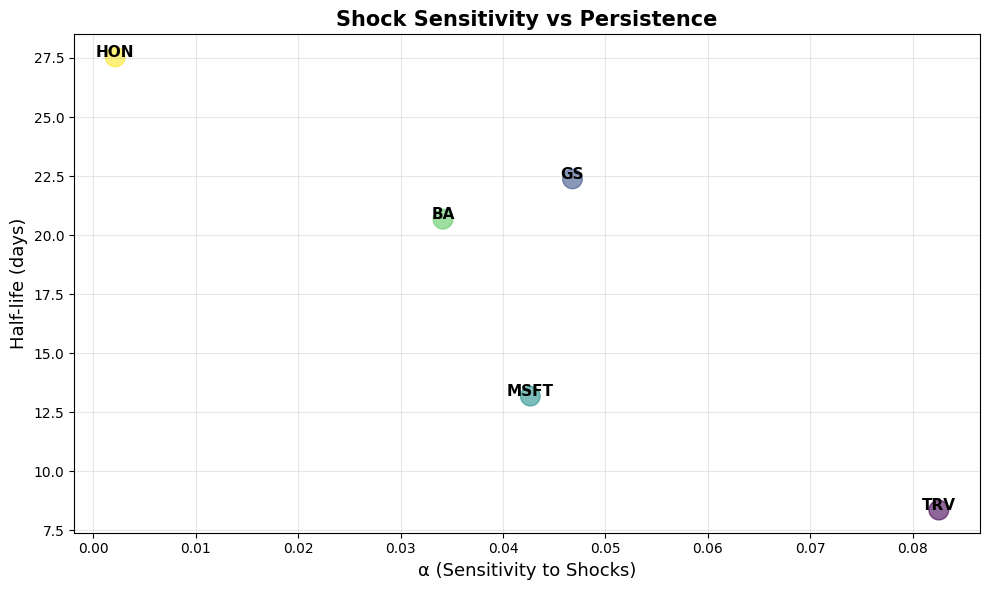


════════════════════════════════════════════════════════════════════════════════


In [29]:
# ── RANKING BY SHOCK SENSITIVITY (ALPHA) ──────────────────────────
print("\n" + "═" * 80)
print("RANKING 1: SHOCK SENSITIVITY (α - ARCH parameter)")
print("═" * 80)
print("Interpretation: Higher α = more reactive to TODAY's market shock")
print("─" * 80)

sensitivity_ranking = (
    df_garch_results[["ticker", "alpha[1]"]]
    .sort_values("alpha[1]", ascending=False)
    .reset_index(drop=True)
)
sensitivity_ranking["sensitivity_rank"] = range(1, len(sensitivity_ranking) + 1)

print(sensitivity_ranking.to_string(index=False))

print("\n MOST SENSITIVE TO TODAY'S SHOCK:")
most_sensitive = sensitivity_ranking.iloc[0]
print(f"   {most_sensitive['ticker']} (α = {most_sensitive['alpha[1]']:.4f})")
print(f"   → A 1% shock today causes {most_sensitive['alpha[1]']:.2%} immediate variance increase")

# ── RANKING BY SHOCK PERSISTENCE (HALF-LIFE) ──────────────────────
print("\n" + "═" * 80)
print("RANKING 2: SHOCK PERSISTENCE (half-life in days)")
print("═" * 80)
print("Interpretation: Longer half-life = shock effects linger LONGER")
print("─" * 80)

persistence_ranking = df_garch_results[["ticker", "alpha[1]", "beta[1]", "persistence"]].copy()

# Calculate half-life: days for shock to decay to 50%
persistence_ranking["half_life_days"] = persistence_ranking["persistence"].apply(
    lambda p: -np.log(2) / np.log(p) if 0 < p < 1 else np.nan
)

persistence_ranking = (
    persistence_ranking
    .sort_values("half_life_days", ascending=False)
    .reset_index(drop=True)
)
persistence_ranking["persistence_rank"] = range(1, len(persistence_ranking) + 1)

print(persistence_ranking[["persistence_rank", "ticker", "persistence", "half_life_days"]].to_string(index=False))

print("\n🎯 LONGEST SHOCK DURATION:")
longest_persist = persistence_ranking.iloc[0]
print(f"   {longest_persist['ticker']} (half-life = {longest_persist['half_life_days']:.1f} days)")
print(f"   → A shock today will still affect volatility {longest_persist['half_life_days']:.0f} days later")

# ── COMPARATIVE ANALYSIS ───────────────────────────────────────────
print("\n" + "═" * 80)
print("COMPARATIVE ANALYSIS: SENSITIVITY vs PERSISTENCE")
print("═" * 80)

comparison = sensitivity_ranking.merge(
    persistence_ranking[["ticker", "persistence_rank", "half_life_days"]],
    on="ticker"
)
comparison["rank_diff"] = comparison["persistence_rank"] - comparison["sensitivity_rank"]

print(comparison[["ticker", "sensitivity_rank", "persistence_rank", "rank_diff", "alpha[1]", "half_life_days"]].to_string(index=False))

# ── VISUALIZATION: SENSITIVITY vs PERSISTENCE SCATTER ──────────────
print("\n" + "═" * 80)
print("GENERATING VISUALIZATION")
print("═" * 80)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    comparison["alpha[1]"],
    comparison["half_life_days"],
    s=200,
    alpha=0.6,
    c=range(len(comparison)),
    cmap="viridis"
)

for _, row in comparison.iterrows():
    ax.annotate(
        row["ticker"],
        (row["alpha[1]"], row["half_life_days"]),
        fontsize=11,
        fontweight='bold',
        ha="center"
    )

ax.set_xlabel("α (Sensitivity to Shocks)", fontsize=13)
ax.set_ylabel("Half-life (days)", fontsize=13)
ax.set_title("Shock Sensitivity vs Persistence", fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "═" * 80)

### 30-Day Volatility Forecasts for Top 5 Stocks

════════════════════════════════════════════════════════════════════════════════
30-DAY VOLATILITY FORECASTS - ALL TOP 5 STOCKS
════════════════════════════════════════════════════════════════════════════════

Forecasting horizon: 30 trading days
Model: GARCH(1,1) fitted to each stock

────────────────────────────────────────────────────────────────────────────────
TICKER: TRV
────────────────────────────────────────────────────────────────────────────────

Forecasted volatility range: 1.35% - 2.19%
Average 30-day volatility:   1.65%

First 5 days:
      date  horizon  vol_forecast_pct
2021-03-24        1          2.185077
2021-03-25        2          2.125399
2021-03-26        3          2.068948
2021-03-29        4          2.015591
2021-03-30        5          1.965199

Last 5 days:
      date  horizon  vol_forecast_pct
2021-04-28       26          1.395776
2021-04-29       27          1.384129
2021-04-30       28          1.373322
2021-05-03       29          1.363299
2021-05-04   

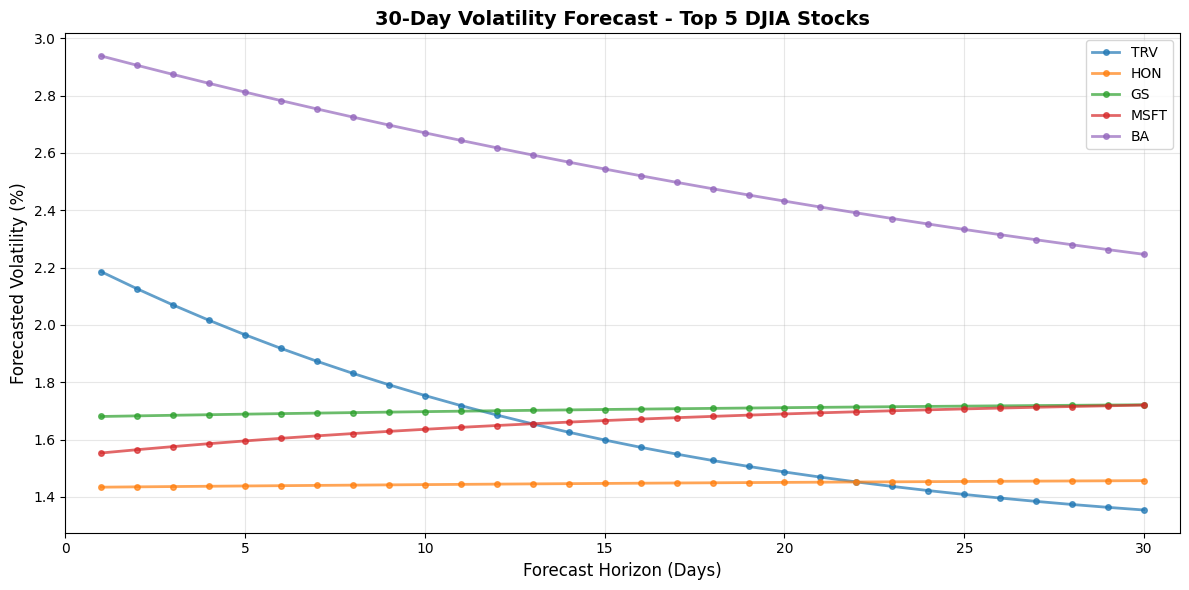


════════════════════════════════════════════════════════════════════════════════
FORECAST INTERPRETATION
════════════════════════════════════════════════════════════════════════════════

 HIGHEST EXPECTED VOLATILITY (30-day average):
   BA: 2.55%
   → Risk management priority for next month

 LOWEST EXPECTED VOLATILITY (30-day average):
   HON: 1.45%
   → Most stable for next month

 DECREASING VOLATILITY TREND:
   TRV: -0.83% (Day 1→30)
   BA: -0.69% (Day 1→30)

════════════════════════════════════════════════════════════════════════════════


In [24]:
# ════════════════════════════════════════════════════════════════════════════════
# 30-DAY VOLATILITY FORECASTS FOR ALL 5 STOCKS
# ════════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

print("═" * 80)
print("30-DAY VOLATILITY FORECASTS - ALL TOP 5 STOCKS")
print("═" * 80)
print(f"\nForecasting horizon: 30 trading days")
print(f"Model: GARCH(1,1) fitted to each stock\n")

# Storage for all forecasts
all_forecasts = {}

# ── GENERATE 30-DAY FORECAST FOR EACH STOCK ────────────────────────────
for ticker in fitted_models.keys():
    print(f"{'─' * 80}")
    print(f"TICKER: {ticker}")
    print(f"{'─' * 80}")
    
    # Get the fitted model
    res = fitted_models[ticker]
    
    # Generate 30-step ahead forecast
    forecast = res.forecast(horizon=30, reindex=False)
    
    # Extract forecasted variance (percent^2)
    var_forecast = forecast.variance.values[-1]  # Last row has all 30 forecasts
    
    # Convert to volatility (percent)
    vol_forecast = np.sqrt(var_forecast)
    
    # NEW (working):
    try:
        last_date = res.model._y_original.index[-1]
    except:
    # Fallback: get from df_long
     ticker_data = df_long[df_long["ticker"] == ticker].sort_values("date")
     last_date = ticker_data["date"].iloc[-1]
     
    # Approximate: 30 trading days ≈ 42 calendar days
    forecast_dates = pd.date_range(
        start=last_date + timedelta(days=1),
        periods=30,
        freq='B'  # Business days
    )
    
    # Store forecast
    forecast_df = pd.DataFrame({
        'date': forecast_dates,
        'vol_forecast_pct': vol_forecast,
        'var_forecast_pct2': var_forecast,
        'horizon': range(1, 31)
    })
    
    all_forecasts[ticker] = forecast_df
    
    # Display summary
    print(f"\nForecasted volatility range: {vol_forecast.min():.2f}% - {vol_forecast.max():.2f}%")
    print(f"Average 30-day volatility:   {vol_forecast.mean():.2f}%")
    print(f"\nFirst 5 days:")
    print(forecast_df.head()[['date', 'horizon', 'vol_forecast_pct']].to_string(index=False))
    print(f"\nLast 5 days:")
    print(forecast_df.tail()[['date', 'horizon', 'vol_forecast_pct']].to_string(index=False))

# ── COMPARISON TABLE ────────────────────────────────────────────────────
print("\n" + "═" * 80)
print("30-DAY FORECAST SUMMARY - ALL STOCKS")
print("═" * 80)

summary_data = []
for ticker, forecast_df in all_forecasts.items():
    summary_data.append({
        'ticker': ticker,
        'avg_vol_30d': forecast_df['vol_forecast_pct'].mean(),
        'day1_vol': forecast_df['vol_forecast_pct'].iloc[0],
        'day30_vol': forecast_df['vol_forecast_pct'].iloc[-1],
        'vol_change': forecast_df['vol_forecast_pct'].iloc[-1] - forecast_df['vol_forecast_pct'].iloc[0],
        'max_vol': forecast_df['vol_forecast_pct'].max(),
        'min_vol': forecast_df['vol_forecast_pct'].min()
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ── VISUALIZATION ───────────────────────────────────────────────────────
print("\n" + "═" * 80)
print("GENERATING 30-DAY FORECAST PLOT")
print("═" * 80)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, (ticker, forecast_df) in enumerate(all_forecasts.items()):
    ax.plot(
        forecast_df['horizon'],
        forecast_df['vol_forecast_pct'],
        label=ticker,
        linewidth=2,
        color=colors[i],
        marker='o',
        markersize=4,
        alpha=0.7
    )

ax.set_xlabel('Forecast Horizon (Days)', fontsize=12)
ax.set_ylabel('Forecasted Volatility (%)', fontsize=12)
ax.set_title('30-Day Volatility Forecast - Top 5 DJIA Stocks', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 31)

plt.tight_layout()
plt.show()

# ── INTERPRETATION ──────────────────────────────────────────────────────
print("\n" + "═" * 80)
print("FORECAST INTERPRETATION")
print("═" * 80)

# Find most/least volatile
most_volatile = summary_df.loc[summary_df['avg_vol_30d'].idxmax()]
least_volatile = summary_df.loc[summary_df['avg_vol_30d'].idxmin()]

print(f"\n HIGHEST EXPECTED VOLATILITY (30-day average):")
print(f"   {most_volatile['ticker']}: {most_volatile['avg_vol_30d']:.2f}%")
print(f"   → Risk management priority for next month")

print(f"\n LOWEST EXPECTED VOLATILITY (30-day average):")
print(f"   {least_volatile['ticker']}: {least_volatile['avg_vol_30d']:.2f}%")
print(f"   → Most stable for next month")

# Identify trends
increasing = summary_df[summary_df['vol_change'] > 0.5].sort_values('vol_change', ascending=False)
decreasing = summary_df[summary_df['vol_change'] < -0.5].sort_values('vol_change')

if not increasing.empty:
    print(f"\n  INCREASING VOLATILITY TREND:")
    for _, row in increasing.iterrows():
        print(f"   {row['ticker']}: +{row['vol_change']:.2f}% (Day 1→30)")

if not decreasing.empty:
    print(f"\n DECREASING VOLATILITY TREND:")
    for _, row in decreasing.iterrows():
        print(f"   {row['ticker']}: {row['vol_change']:.2f}% (Day 1→30)")

print("\n" + "═" * 80)

### Ranked five stocks by order of most likely to be bothered by a shock to the market today

In [25]:
# ════════════════════════════════════════════════════════════════
# RANK STOCKS BY SHOCK SENSITIVITY AND PERSISTENCE
# ════════════════════════════════════════════════════════════════

import numpy as np

print("═" * 80)
print("STOCK RANKINGS BASED ON VOLATILITY DYNAMICS")
print("═" * 80)


# ── 1️ RANK BY SHOCK SENSITIVITY (ALPHA) ─────────────────────────
print("\nRANKING 1: MOST BOTHERED BY TODAY'S MARKET SHOCK")
print("Higher α = stronger immediate reaction to new information")
print("─" * 80)

sensitivity_ranking = (
    df_garch_results[["ticker", "alpha[1]"]]
    .sort_values("alpha[1]", ascending=False)
    .reset_index(drop=True)
)

sensitivity_ranking["rank"] = range(1, len(sensitivity_ranking) + 1)

print(sensitivity_ranking.to_string(index=False))


# Top stock
most_sensitive = sensitivity_ranking.iloc[0]
print("\nTOP STOCK (MOST SENSITIVE):")
print(f"{most_sensitive['ticker']}  |  α = {most_sensitive['alpha[1]']:.4f}")


════════════════════════════════════════════════════════════════════════════════
STOCK RANKINGS BASED ON VOLATILITY DYNAMICS
════════════════════════════════════════════════════════════════════════════════

RANKING 1: MOST BOTHERED BY TODAY'S MARKET SHOCK
Higher α = stronger immediate reaction to new information
────────────────────────────────────────────────────────────────────────────────
ticker  alpha[1]  rank
   TRV  0.082541     1
    GS  0.046781     2
  MSFT  0.042667     3
    BA  0.034142     4
   HON  0.002147     5

TOP STOCK (MOST SENSITIVE):
TRV  |  α = 0.0825


### Ranked five stocks by order of longest effect a shock lasts; compared to the previous ranking and interpret

In [26]:
### Code Here

# ──  RANK BY SHOCK PERSISTENCE (HALF-LIFE) ─────────────────────
print("\n" + "═" * 80)
print("RANKING 2: LONGEST LASTING SHOCK EFFECT")
print("Longer half-life = volatility impact persists longer")
print("─" * 80)

persistence_df = df_garch_results[["ticker", "alpha[1]", "beta[1]", "persistence"]].copy()

# Half-life formula
persistence_df["half_life_days"] = persistence_df["persistence"].apply(
    lambda p: -np.log(2) / np.log(p) if 0 < p < 1 else np.nan
)

persistence_ranking = (
    persistence_df
    .sort_values("half_life_days", ascending=False)
    .reset_index(drop=True)
)

persistence_ranking["rank"] = range(1, len(persistence_ranking) + 1)

print(persistence_ranking[["rank", "ticker", "persistence", "half_life_days"]].to_string(index=False))


# Top persistent stock
longest_persist = persistence_ranking.iloc[0]
print("\nTOP STOCK (LONGEST EFFECT):")
print(f"{longest_persist['ticker']}  |  Half-life = {longest_persist['half_life_days']:.1f} days")


# ──  COMPARE BOTH RANKINGS ─────────────────────────────────────
print("\n" + "═" * 80)
print("COMPARISON: SENSITIVITY vs PERSISTENCE")
print("═" * 80)

comparison = sensitivity_ranking.merge(
    persistence_ranking[["ticker", "rank", "half_life_days"]],
    on="ticker",
    suffixes=("_sensitivity", "_persistence")
)

print(comparison.to_string(index=False))


# ── FINAL ORDERED LISTS ──────────────────────────────────────────
print("\nFINAL ORDER:")
print("\nMost sensitive to today's shock:")
for i, row in sensitivity_ranking.iterrows():
    print(f"{i+1}. {row['ticker']}")

print("\nLongest lasting shock:")
for i, row in persistence_ranking.iterrows():
    print(f"{i+1}. {row['ticker']} ({row['half_life_days']:.1f} days)")


════════════════════════════════════════════════════════════════════════════════
RANKING 2: LONGEST LASTING SHOCK EFFECT
Longer half-life = volatility impact persists longer
────────────────────────────────────────────────────────────────────────────────
 rank ticker  persistence  half_life_days
    1    HON     0.975147       27.542025
    2     GS     0.969504       22.380558
    3     BA     0.967033       20.676934
    4   MSFT     0.948792       13.186313
    5    TRV     0.920440        8.360909

TOP STOCK (LONGEST EFFECT):
HON  |  Half-life = 27.5 days

════════════════════════════════════════════════════════════════════════════════
COMPARISON: SENSITIVITY vs PERSISTENCE
════════════════════════════════════════════════════════════════════════════════
ticker  alpha[1]  rank_sensitivity  rank_persistence  half_life_days
   TRV  0.082541                 1                 5        8.360909
    GS  0.046781                 2                 2       22.380558
  MSFT  0.042667        